<a href="https://colab.research.google.com/github/fatenahaq-blip/monte-carlo-portfolio-simulation/blob/main/monte_carlo_portfolio_simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Monte Carlo Portfolio Simulation

## Project objective

This project uses Monte Carlo simulation to estimate possible future portfolio outcomes.

The project will:

1. Download historical asset prices.
2. Calculate historical returns and risk.
3. Build a diversified portfolio.
4. Simulate 10,000 possible future portfolio paths.
5. estimate possible final portfolio values.
6. Calculate probability of loss.
7. Calculate Value at Risk and Expected Shortfall.
8. Test optimistic and pessimistic scenarios.

## What is Monte Carlo simulation?

Imagine rolling a die once.

You cannot know the exact number before you roll it.

However, if you roll the die 10,000 times, you can understand:

- the most common results;
- the best possible results;
- the worst possible results;
- how often each result happens.

Financial markets are more complicated than dice, but the main idea is similar.

A Monte Carlo simulation creates thousands of possible market paths so that we can study portfolio uncertainty and risk.

In [ ]:
!pip install -q yfinance

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

print("All tools are ready.")

All tools are ready.


## Portfolio assets

The portfolio contains four asset classes:

- SPY: large US companies
- QQQ: technology-focused US companies
- BND: US bonds
- GLD: gold

The portfolio is simplified for educational purposes.

In [ ]:
tickers = ["SPY", "QQQ", "BND", "GLD"]

asset_names = {
    "SPY": "US Equities",
    "QQQ": "Technology Equities",
    "BND": "US Bonds",
    "GLD": "Gold"
}

print("Portfolio assets:")

for ticker in tickers:
    print(ticker, "-", asset_names[ticker])

Portfolio assets:
SPY - US Equities
QQQ - Technology Equities
BND - US Bonds
GLD - Gold


In [ ]:
weights = np.array([
    0.40,
    0.25,
    0.25,
    0.10
])

print("Total portfolio weight:", weights.sum())

Total portfolio weight: 1.0


In [ ]:
portfolio_allocation = pd.DataFrame({
    "Ticker": tickers,
    "Asset": [asset_names[ticker] for ticker in tickers],
    "Weight": weights
})

portfolio_allocation["Weight (%)"] = (
    portfolio_allocation["Weight"] * 100
)

portfolio_allocation[
    ["Ticker", "Asset", "Weight (%)"]
]

,Ticker,Asset,Weight (%)
0,SPY,US Equities,40.0
1,QQQ,Technology Equities,25.0
2,BND,US Bonds,25.0
3,GLD,Gold,10.0


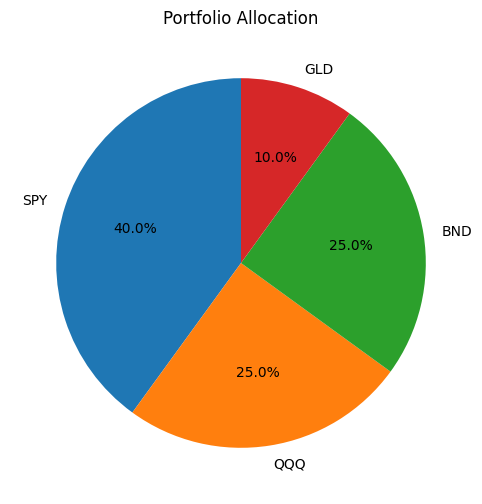

In [ ]:
plt.figure(figsize=(8, 6))

plt.pie(
    portfolio_allocation["Weight (%)"],
    labels=portfolio_allocation["Ticker"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Portfolio Allocation")
plt.show()

In [ ]:
prices = yf.download(
    tickers=tickers,
    start="2015-01-01",
    end="2026-01-01",
    auto_adjust=True,
    progress=False
)["Close"]

print("Historical data downloaded.")
print("Number of rows:", prices.shape[0])
print("Number of assets:", prices.shape[1])

prices.head()

Historical data downloaded.
Number of rows: 2766
Number of assets: 4


Ticker,BND,GLD,QQQ,SPY
Date,,,,
2015-01-02,59.205677,114.080002,94.561150,169.687866
2015-01-05,59.377583,115.800003,93.174057,166.623367
2015-01-06,59.549515,117.120003,91.924759,165.053940
2015-01-07,59.585281,116.430000,93.109741,167.110672
2015-01-08,59.492214,115.940002,94.891853,170.076065


In [ ]:
prices = prices[tickers]

prices.head()

Ticker,SPY,QQQ,BND,GLD
Date,,,,
2015-01-02,169.687866,94.561150,59.205677,114.080002
2015-01-05,166.623367,93.174057,59.377583,115.800003
2015-01-06,165.053940,91.924759,59.549515,117.120003
2015-01-07,167.110672,93.109741,59.585281,116.430000
2015-01-08,170.076065,94.891853,59.492214,115.940002


In [ ]:
missing_values = prices.isna().sum()

missing_values

,0
Ticker,
SPY,0
QQQ,0
BND,0
GLD,0


In [ ]:
prices = prices.ffill().dropna()

print("Missing values remaining:")
print(prices.isna().sum())

Missing values remaining:
Ticker
SPY    0
QQQ    0
BND    0
GLD    0
dtype: int64


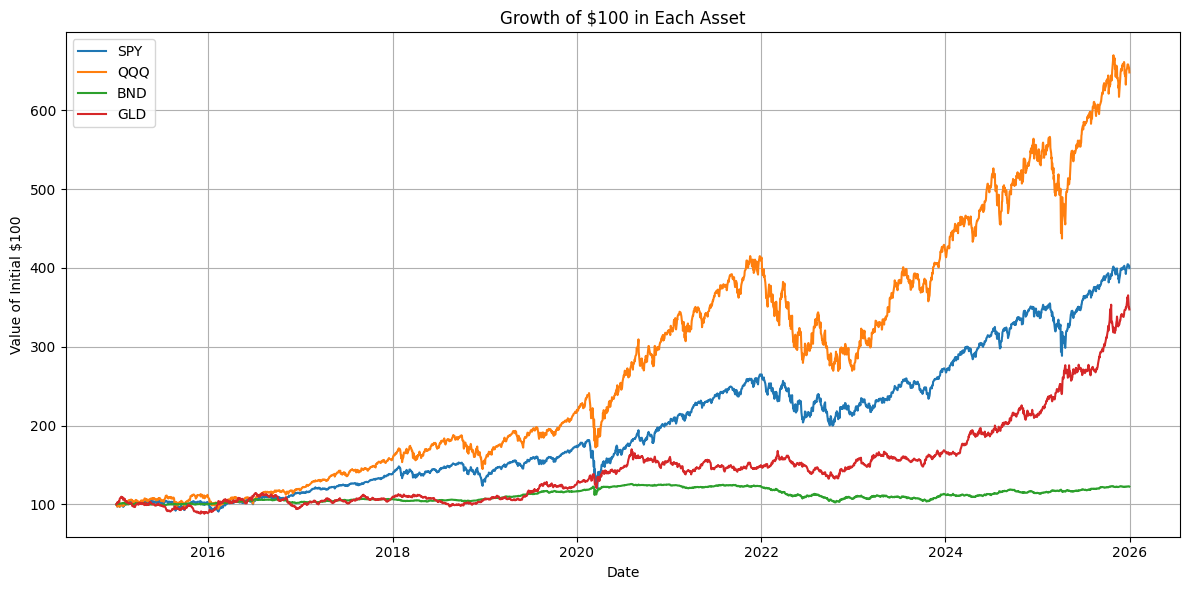

In [ ]:
normalized_prices = prices / prices.iloc[0] * 100

plt.figure(figsize=(12, 6))

for ticker in tickers:
    plt.plot(
        normalized_prices.index,
        normalized_prices[ticker],
        label=ticker
    )

plt.title("Growth of $100 in Each Asset")
plt.xlabel("Date")
plt.ylabel("Value of Initial $100")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
daily_returns = prices.pct_change().dropna()

daily_returns.head()

Ticker,SPY,QQQ,BND,GLD
Date,,,,
2015-01-05,-0.018060,-0.014669,0.002904,0.015077
2015-01-06,-0.009419,-0.013408,0.002896,0.011399
2015-01-07,0.012461,0.012891,0.000601,-0.005891
2015-01-08,0.017745,0.019140,-0.001562,-0.004209
2015-01-09,-0.008014,-0.006583,0.001685,0.011385


In [ ]:
trading_days = 252

annual_asset_returns = (
    daily_returns.mean() * trading_days
)

annual_asset_returns


,0
Ticker,
SPY,0.142186
QQQ,0.194586
BND,0.020057
GLD,0.124400


In [ ]:
annual_asset_volatility = (
    daily_returns.std() * np.sqrt(trading_days)
)

annual_asset_volatility

,0
Ticker,
SPY,0.177925
QQQ,0.219817
BND,0.053640
GLD,0.147472


In [ ]:
asset_statistics = pd.DataFrame({
    "Annual Return": annual_asset_returns,
    "Annual Volatility": annual_asset_volatility
})

asset_statistics["Annual Return (%)"] = (
    asset_statistics["Annual Return"] * 100
)

asset_statistics["Annual Volatility (%)"] = (
    asset_statistics["Annual Volatility"] * 100
)

asset_statistics[
    ["Annual Return (%)", "Annual Volatility (%)"]
].round(2)

,Annual Return (%),Annual Volatility (%)
Ticker,,
SPY,14.22,17.79
QQQ,19.46,21.98
BND,2.01,5.36
GLD,12.44,14.75


In [ ]:
portfolio_daily_returns = (
    daily_returns @ weights
)

portfolio_daily_returns.name = "Portfolio Return"

portfolio_daily_returns.head()

,Portfolio Return
Date,
2015-01-05,-0.008657
2015-01-06,-0.005256
2015-01-07,0.007768
2015-01-08,0.011072
2015-01-09,-0.003291


In [ ]:
expected_annual_return = (
    portfolio_daily_returns.mean() * trading_days
)

print(
    "Expected annual portfolio return:",
    f"{expected_annual_return:.2%}"
)

Expected annual portfolio return: 12.30%


In [ ]:
annual_portfolio_volatility = (
    portfolio_daily_returns.std()
    * np.sqrt(trading_days)
)

print(
    "Annual portfolio volatility:",
    f"{annual_portfolio_volatility:.2%}"
)

Annual portfolio volatility: 12.83%


In [ ]:
correlation_matrix = daily_returns.corr()

correlation_matrix.round(2)

Ticker,SPY,QQQ,BND,GLD
Ticker,,,,
SPY,1.00,0.93,0.11,0.04
QQQ,0.93,1.00,0.11,0.05
BND,0.11,0.11,1.00,0.33
GLD,0.04,0.05,0.33,1.00


In [ ]:
initial_investment = 100_000

print(
    f"Starting portfolio value: ${initial_investment:,.2f}"
)

Starting portfolio value: $100,000.00


In [ ]:
years = 10
trading_days_per_year = 252
simulation_days = years * trading_days_per_year

number_of_simulations = 10_000

print("Simulation years:", years)
print("Days in each simulation:", simulation_days)
print("Number of simulations:", number_of_simulations)

Simulation years: 10
Days in each simulation: 2520
Number of simulations: 10000


In [ ]:
mean_daily_return = portfolio_daily_returns.mean()
daily_volatility = portfolio_daily_returns.std()

print("Mean daily return:", mean_daily_return)
print("Daily volatility:", daily_volatility)

Mean daily return: 0.00048799800080477043
Daily volatility: 0.008081179982577574


In [ ]:
random_seed = 42
rng = np.random.default_rng(random_seed)

print("Random-number generator is ready.")

Random-number generator is ready.


In [ ]:
simulated_daily_returns = rng.normal(
    loc=mean_daily_return,
    scale=daily_volatility,
    size=(simulation_days, number_of_simulations)
)

print("Simulation table shape:")
print(simulated_daily_returns.shape)

Simulation table shape:
(2520, 10000)


In [ ]:
portfolio_paths = initial_investment * np.cumprod(
    1 + simulated_daily_returns,
    axis=0
)

print("Portfolio paths created.")

Portfolio paths created.


In [ ]:
print("Portfolio-path table shape:")
print(portfolio_paths.shape)

print(
    "First simulated ending value:",
    f"${portfolio_paths[-1, 0]:,.2f}"
)

Portfolio-path table shape:
(2520, 10000)
First simulated ending value: $514,452.13


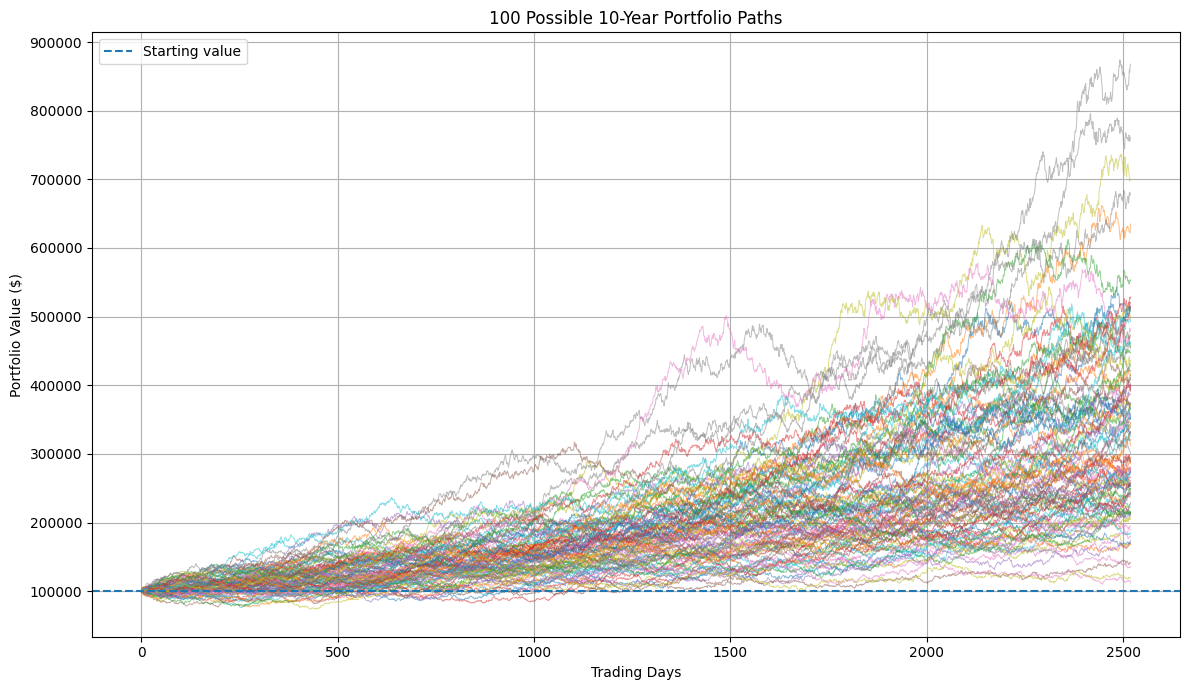

In [ ]:
plt.figure(figsize=(12, 7))

plt.plot(
    portfolio_paths[:, :100],
    linewidth=0.7,
    alpha=0.5
)

plt.axhline(
    initial_investment,
    linestyle="--",
    label="Starting value"
)

plt.title("100 Possible 10-Year Portfolio Paths")
plt.xlabel("Trading Days")
plt.ylabel("Portfolio Value ($)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
ending_values = portfolio_paths[-1, :]

print("Number of ending values:", len(ending_values))

Number of ending values: 10000


In [ ]:
percentile_5 = np.percentile(ending_values, 5)
percentile_25 = np.percentile(ending_values, 25)
median_ending_value = np.percentile(ending_values, 50)
percentile_75 = np.percentile(ending_values, 75)
percentile_95 = np.percentile(ending_values, 95)

print(f"5th percentile:  ${percentile_5:,.2f}")
print(f"25th percentile: ${percentile_25:,.2f}")
print(f"Median outcome:  ${median_ending_value:,.2f}")
print(f"75th percentile: ${percentile_75:,.2f}")
print(f"95th percentile: ${percentile_95:,.2f}")

5th percentile:  $161,911.22
25th percentile: $239,783.86
Median outcome:  $314,188.58
75th percentile: $415,781.43
95th percentile: $622,496.98


In [ ]:
outcome_table = pd.DataFrame({
    "Scenario": [
        "Poor outcome",
        "Below-average outcome",
        "Middle outcome",
        "Above-average outcome",
        "Strong outcome"
    ],
    "Percentile": [
        "5th",
        "25th",
        "50th",
        "75th",
        "95th"
    ],
    "Ending Portfolio Value": [
        percentile_5,
        percentile_25,
        median_ending_value,
        percentile_75,
        percentile_95
    ]
})

outcome_table["Ending Portfolio Value"] = (
    outcome_table["Ending Portfolio Value"]
    .map(lambda value: f"${value:,.2f}")
)

outcome_table

,Scenario,Percentile,Ending Portfolio Value
0,Poor outcome,5th,"$161,911.22"
1,Below-average outcome,25th,"$239,783.86"
2,Middle outcome,50th,"$314,188.58"
3,Above-average outcome,75th,"$415,781.43"
4,Strong outcome,95th,"$622,496.98"


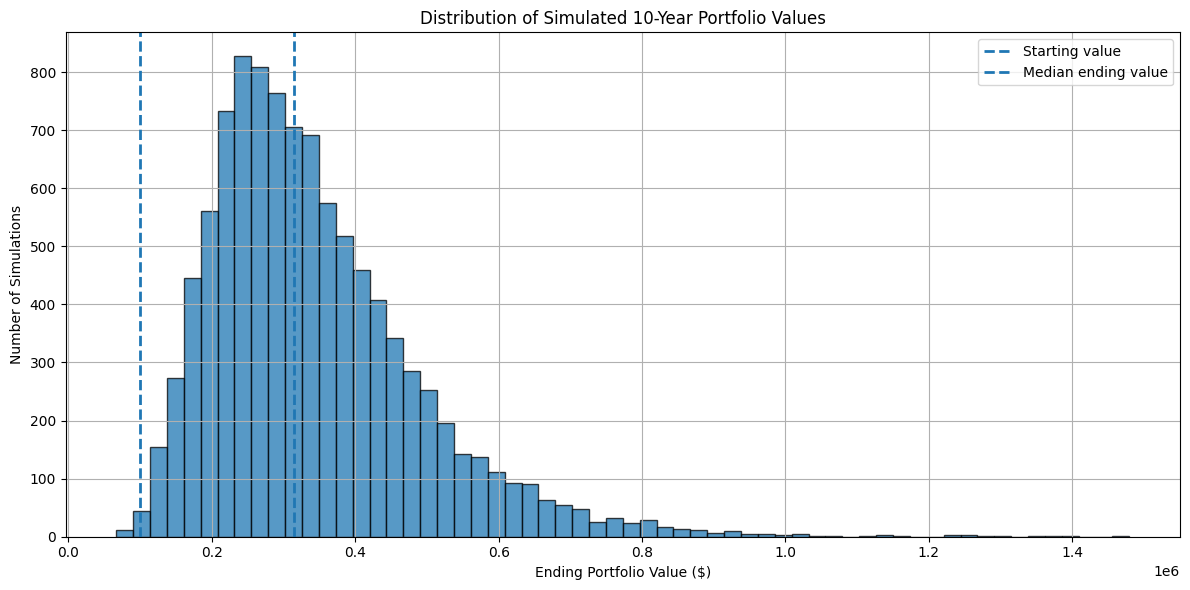

In [ ]:
plt.figure(figsize=(12, 6))

plt.hist(
    ending_values,
    bins=60,
    edgecolor="black",
    alpha=0.75
)

plt.axvline(
    initial_investment,
    linestyle="--",
    linewidth=2,
    label="Starting value"
)

plt.axvline(
    median_ending_value,
    linestyle="--",
    linewidth=2,
    label="Median ending value"
)

plt.title("Distribution of Simulated 10-Year Portfolio Values")
plt.xlabel("Ending Portfolio Value ($)")
plt.ylabel("Number of Simulations")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
probability_of_loss = np.mean(
    ending_values < initial_investment
)

print(
    "Probability of ending below the starting value:",
    f"{probability_of_loss:.2%}"
)

Probability of ending below the starting value: 0.21%


In [ ]:
target_value = 200_000

probability_of_reaching_target = np.mean(
    ending_values >= target_value
)

print(
    f"Probability of reaching ${target_value:,.0f}:",
    f"{probability_of_reaching_target:.2%}"
)

Probability of reaching $200,000: 87.14%


In [ ]:
profits_and_losses = (
    ending_values - initial_investment
)

print(
    "Average simulated profit or loss:",
    f"${profits_and_losses.mean():,.2f}"
)

Average simulated profit or loss: $242,971.94


In [ ]:
simulated_total_returns = (
    ending_values / initial_investment - 1
)

print(
    "Median simulated total return:",
    f"{np.median(simulated_total_returns):.2%}"
)

Median simulated total return: 214.19%


In [ ]:
confidence_level = 0.95

losses = initial_investment - ending_values

value_at_risk = np.percentile(
    losses,
    confidence_level * 100
)

value_at_risk = max(value_at_risk, 0)

print(
    "95% simulated 10-year Value at Risk:",
    f"${value_at_risk:,.2f}"
)

95% simulated 10-year Value at Risk: $0.00


In [ ]:
var_threshold = np.percentile(
    losses,
    confidence_level * 100
)

tail_losses = losses[
    losses >= var_threshold
]

expected_shortfall = tail_losses.mean()

expected_shortfall = max(expected_shortfall, 0)

print(
    "95% simulated Expected Shortfall:",
    f"${expected_shortfall:,.2f}"
)

95% simulated Expected Shortfall: $0.00


In [ ]:
running_peaks = np.maximum.accumulate(
    portfolio_paths,
    axis=0
)

drawdowns = (
    portfolio_paths / running_peaks - 1
)

maximum_drawdowns = drawdowns.min(axis=0)

In [ ]:
median_maximum_drawdown = np.median(
    maximum_drawdowns
)

severe_drawdown = np.percentile(
    maximum_drawdowns,
    5
)

print(
    "Median maximum drawdown:",
    f"{median_maximum_drawdown:.2%}"
)

print(
    "Severe 5th-percentile maximum drawdown:",
    f"{severe_drawdown:.2%}"
)

Median maximum drawdown: -20.27%
Severe 5th-percentile maximum drawdown: -32.35%


In [ ]:
probability_20_percent_drawdown = np.mean(
    maximum_drawdowns <= -0.20
)

print(
    "Probability of experiencing at least a 20% drawdown:",
    f"{probability_20_percent_drawdown:.2%}"
)

Probability of experiencing at least a 20% drawdown: 51.99%


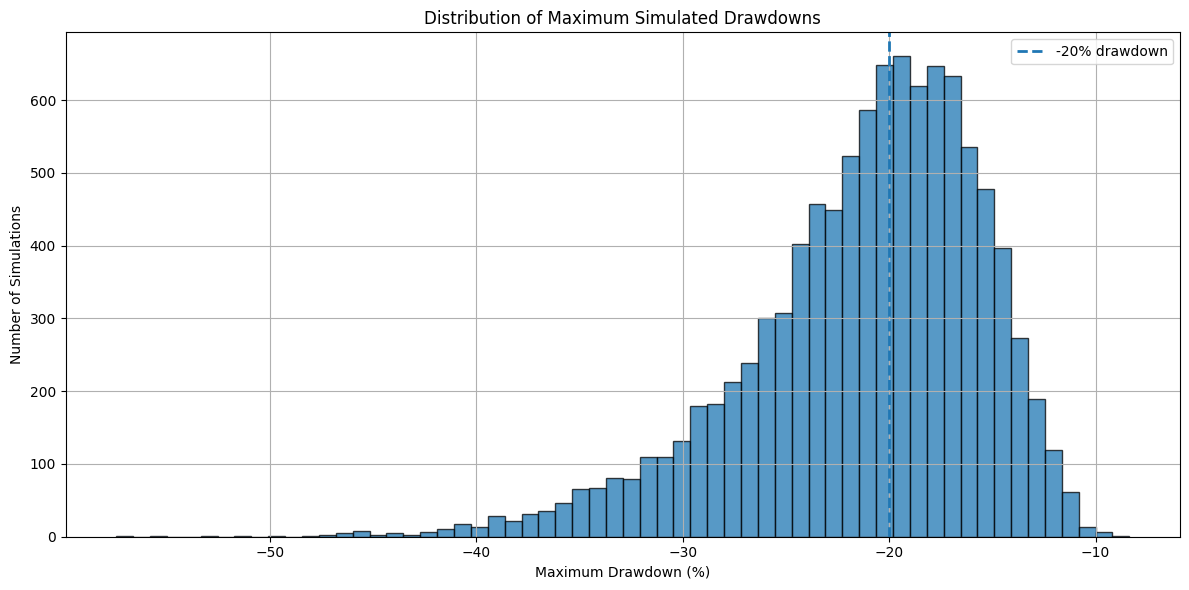

In [ ]:
plt.figure(figsize=(12, 6))

plt.hist(
    maximum_drawdowns * 100,
    bins=60,
    edgecolor="black",
    alpha=0.75
)

plt.axvline(
    -20,
    linestyle="--",
    linewidth=2,
    label="-20% drawdown"
)

plt.title("Distribution of Maximum Simulated Drawdowns")
plt.xlabel("Maximum Drawdown (%)")
plt.ylabel("Number of Simulations")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
simulation_summary = pd.DataFrame({
    "Metric": [
        "Starting portfolio value",
        "Expected annual return assumption",
        "Annual volatility assumption",
        "Median ending value",
        "5th-percentile ending value",
        "95th-percentile ending value",
        "Probability of ending with a loss",
        "Probability of reaching target",
        "95% Value at Risk",
        "95% Expected Shortfall",
        "Median maximum drawdown",
        "Probability of at least 20% drawdown"
    ],
    "Result": [
        f"${initial_investment:,.2f}",
        f"{expected_annual_return:.2%}",
        f"{annual_portfolio_volatility:.2%}",
        f"${median_ending_value:,.2f}",
        f"${percentile_5:,.2f}",
        f"${percentile_95:,.2f}",
        f"{probability_of_loss:.2%}",
        f"{probability_of_reaching_target:.2%}",
        f"${value_at_risk:,.2f}",
        f"${expected_shortfall:,.2f}",
        f"{median_maximum_drawdown:.2%}",
        f"{probability_20_percent_drawdown:.2%}"
    ]
})

simulation_summary

,Metric,Result
0,Starting portfolio value,"$100,000.00"
1,Expected annual return assumption,12.30%
2,Annual volatility assumption,12.83%
3,Median ending value,"$314,188.58"
4,5th-percentile ending value,"$161,911.22"
5,95th-percentile ending value,"$622,496.98"
6,Probability of ending with a loss,0.21%
7,Probability of reaching target,87.14%
8,95% Value at Risk,$0.00
9,95% Expected Shortfall,$0.00


In [ ]:
degrees_of_freedom = 5

t_random_values = rng.standard_t(
    df=degrees_of_freedom,
    size=(simulation_days, number_of_simulations)
)

t_random_values = (
    t_random_values
    / np.sqrt(
        degrees_of_freedom
        / (degrees_of_freedom - 2)
    )
)

fat_tail_returns = (
    mean_daily_return
    + daily_volatility * t_random_values
)

In [ ]:
fat_tail_paths = initial_investment * np.cumprod(
    1 + fat_tail_returns,
    axis=0
)

fat_tail_ending_values = fat_tail_paths[-1, :]

In [ ]:
comparison_table = pd.DataFrame({
    "Metric": [
        "5th-percentile ending value",
        "Median ending value",
        "Probability of loss"
    ],
    "Normal Model": [
        np.percentile(ending_values, 5),
        np.median(ending_values),
        np.mean(ending_values < initial_investment)
    ],
    "Fat-Tail Model": [
        np.percentile(fat_tail_ending_values, 5),
        np.median(fat_tail_ending_values),
        np.mean(
            fat_tail_ending_values < initial_investment
        )
    ]
})

comparison_table

,Metric,Normal Model,Fat-Tail Model
0,5th-percentile ending value,161911.218962,162349.178059
1,Median ending value,314188.576703,319250.937825
2,Probability of loss,0.002100,0.002300


In [ ]:
formatted_comparison = comparison_table.copy()

formatted_comparison.loc[
    formatted_comparison["Metric"]
    != "Probability of loss",
    ["Normal Model", "Fat-Tail Model"]
] = formatted_comparison.loc[
    formatted_comparison["Metric"]
    != "Probability of loss",
    ["Normal Model", "Fat-Tail Model"]
].map(lambda value: f"${value:,.2f}")

formatted_comparison.loc[
    formatted_comparison["Metric"]
    == "Probability of loss",
    ["Normal Model", "Fat-Tail Model"]
] = formatted_comparison.loc[
    formatted_comparison["Metric"]
    == "Probability of loss",
    ["Normal Model", "Fat-Tail Model"]
].map(lambda value: f"{value:.2%}")

formatted_comparison

,Metric,Normal Model,Fat-Tail Model
0,5th-percentile ending value,"$161,911.22","$162,349.18"
1,Median ending value,"$314,188.58","$319,250.94"
2,Probability of loss,0.21%,0.23%


In [ ]:
stressed_annual_return = (
    expected_annual_return - 0.03
)

stressed_annual_volatility = (
    annual_portfolio_volatility * 1.25
)

stressed_daily_return = (
    stressed_annual_return / trading_days
)

stressed_daily_volatility = (
    stressed_annual_volatility
    / np.sqrt(trading_days)
)

In [ ]:
stressed_random_returns = rng.normal(
    loc=stressed_daily_return,
    scale=stressed_daily_volatility,
    size=(simulation_days, number_of_simulations)
)

stressed_paths = initial_investment * np.cumprod(
    1 + stressed_random_returns,
    axis=0
)

stressed_ending_values = stressed_paths[-1, :]

In [ ]:
scenario_comparison = pd.DataFrame({
    "Scenario": [
        "Base case",
        "Stressed case"
    ],
    "Median Ending Value": [
        np.median(ending_values),
        np.median(stressed_ending_values)
    ],
    "5th-Percentile Ending Value": [
        np.percentile(ending_values, 5),
        np.percentile(stressed_ending_values, 5)
    ],
    "Probability of Loss": [
        np.mean(ending_values < initial_investment),
        np.mean(
            stressed_ending_values
            < initial_investment
        )
    ]
})

scenario_comparison

,Scenario,Median Ending Value,5th-Percentile Ending Value,Probability of Loss
0,Base case,314188.576703,161911.218962,0.0021
1,Stressed case,222290.731572,96543.176036,0.0588


In [ ]:
scenario_display = scenario_comparison.copy()

scenario_display["Median Ending Value"] = (
    scenario_display["Median Ending Value"]
    .map(lambda value: f"${value:,.2f}")
)

scenario_display["5th-Percentile Ending Value"] = (
    scenario_display["5th-Percentile Ending Value"]
    .map(lambda value: f"${value:,.2f}")
)

scenario_display["Probability of Loss"] = (
    scenario_display["Probability of Loss"]
    .map(lambda value: f"{value:.2%}")
)

scenario_display

,Scenario,Median Ending Value,5th-Percentile Ending Value,Probability of Loss
0,Base case,"$314,188.58","$161,911.22",0.21%
1,Stressed case,"$222,290.73","$96,543.18",5.88%


In [ ]:
def analyze_portfolio(
    asset_returns,
    portfolio_weights,
    initial_value=100_000,
    years=10,
    simulations=5_000,
    seed=42
):
    portfolio_returns = (
        asset_returns @ portfolio_weights
    )

    mean_return = portfolio_returns.mean()
    volatility = portfolio_returns.std()

    days = years * 252
    generator = np.random.default_rng(seed)

    random_returns = generator.normal(
        loc=mean_return,
        scale=volatility,
        size=(days, simulations)
    )

    paths = initial_value * np.cumprod(
        1 + random_returns,
        axis=0
    )

    final_values = paths[-1, :]

    return {
        "Annual Return": mean_return * 252,
        "Annual Volatility": volatility * np.sqrt(252),
        "Median Ending Value": np.median(final_values),
        "5th Percentile": np.percentile(final_values, 5),
        "Probability of Loss": np.mean(
            final_values < initial_value
        )
    }

In [ ]:
portfolio_options = {
    "Conservative": np.array([
        0.20, 0.10, 0.60, 0.10
    ]),
    "Balanced": np.array([
        0.40, 0.25, 0.25, 0.10
    ]),
    "Growth": np.array([
        0.50, 0.35, 0.05, 0.10
    ])
}

In [ ]:
allocation_results = []

for name, allocation in portfolio_options.items():
    result = analyze_portfolio(
        asset_returns=daily_returns,
        portfolio_weights=allocation
    )

    allocation_results.append({
        "Portfolio": name,
        **result
    })

allocation_comparison = pd.DataFrame(
    allocation_results
)

allocation_comparison

,Portfolio,Annual Return,Annual Volatility,Median Ending Value,5th Percentile,Probability of Loss
0,Conservative,0.072370,0.072490,201699.709747,137251.373870,0.0010
1,Balanced,0.122975,0.128285,317239.007661,160648.686403,0.0024
2,Growth,0.152641,0.164914,405290.255571,169164.862001,0.0034


In [ ]:
allocation_display = allocation_comparison.copy()

percentage_columns = [
    "Annual Return",
    "Annual Volatility",
    "Probability of Loss"
]

for column in percentage_columns:
    allocation_display[column] = (
        allocation_display[column]
        .map(lambda value: f"{value:.2%}")
    )

money_columns = [
    "Median Ending Value",
    "5th Percentile"
]

for column in money_columns:
    allocation_display[column] = (
        allocation_display[column]
        .map(lambda value: f"${value:,.2f}")
    )

allocation_display

,Portfolio,Annual Return,Annual Volatility,Median Ending Value,5th Percentile,Probability of Loss
0,Conservative,7.24%,7.25%,"$201,699.71","$137,251.37",0.10%
1,Balanced,12.30%,12.83%,"$317,239.01","$160,648.69",0.24%
2,Growth,15.26%,16.49%,"$405,290.26","$169,164.86",0.34%


## Conclusion

This project used historical market data and Monte Carlo simulation to estimate possible ten-year outcomes for a diversified investment portfolio.

The portfolio consisted of US equities (SPY), technology equities (QQQ), US bonds (BND), and gold (GLD). Historical daily returns were used to estimate expected return and volatility, and 10,000 future portfolio paths were simulated.

### Main Results

- **Starting portfolio value:** $100,000
- **Expected annual return assumption:** 12.30%
- **Annual volatility assumption:** 12.83%
- **Median simulated ending value:** $314,188.58
- **5th-percentile ending value:** $161,911.22
- **95th-percentile ending value:** $622,496.98
- **Probability of ending below the initial investment:** 0.21%
- **Probability of reaching the target portfolio value:** 87.14%
- **95% Value at Risk (VaR):** $0.00
- **95% Expected Shortfall (ES):** $0.00
- **Median maximum drawdown:** -20.27%
- **Probability of experiencing at least a 20% drawdown:** 51.99%

### Interpretation

The simulation suggests that the portfolio has a strong long-term growth profile under the assumptions used in the model. The median ending portfolio value after ten years was approximately **$314,189**, more than three times the initial investment.

Only **0.21%** of the simulated scenarios ended below the initial investment, while **87.14%** reached or exceeded the target portfolio value of **$200,000**.

Although the probability of a permanent loss was very low, the simulation also showed that investors should expect periods of significant market declines. The median maximum drawdown was approximately **20.27%**, and about **52%** of simulations experienced a drawdown of at least **20%** at some point during the investment horizon.

The reported **Value at Risk (VaR)** and **Expected Shortfall (ES)** are both **$0.00** because, over the full ten-year horizon and under the model assumptions, even the 5th-percentile ending portfolio value remained above the initial investment. This indicates that the simulated long-term loss threshold was not breached at the selected confidence level. However, this should **not** be interpreted as the portfolio being risk-free, as substantial temporary drawdowns were still observed.

### Limitations

1. Historical returns and volatility may not accurately represent future market conditions.
2. The simulation assumes that expected returns and volatility remain constant throughout the investment period.
3. The normal distribution may underestimate the probability of extreme market events; although a fat-tail model was also explored, it remains a simplified representation.
4. Taxes, transaction costs, inflation, management fees, and portfolio withdrawals were not incorporated.
5. Asset correlations were assumed to remain stable, even though they often change during periods of market stress.
6. The portfolio contains only four ETFs and does not represent the full global investment universe.
7. Monte Carlo simulation estimates a range of possible outcomes based on assumptions; it does not predict future market performance or guarantee investment results.

### Future Improvements

- Include periodic contributions and withdrawals.
- Model inflation-adjusted portfolio values.
- Use stochastic interest rates and volatility models.
- Compare multiple asset allocations using efficient frontiers.
- Incorporate regime-switching models and changing correlations.
- Build an interactive dashboard using Streamlit or Plotly.
- Validate results using historical backtesting and bootstrap simulations.